In [1]:
# Step 01: Imported Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Step 02: Load Data

In [4]:
df = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (913000, 4)

First 5 rows:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
# Step 03: Check for missing values

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Missing values per column:
date     0
store    0
item     0
sales    0
dtype: int64

Data types:
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

Basic statistics:


,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [7]:
# Step 04: Plotting total daily sales over time

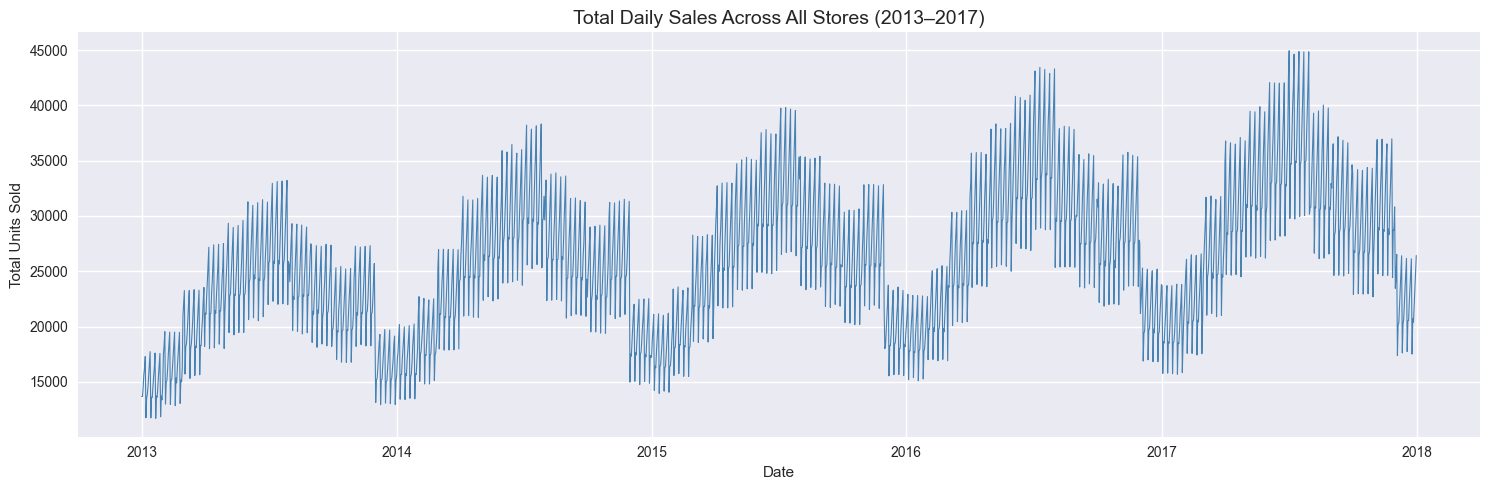

Chart saved to results/overall_trend.png


In [8]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], linewidth=0.8, color='steelblue')
plt.title('Total Daily Sales Across All Stores (2013–2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.savefig('../results/overall_trend.png', dpi=150)
plt.show()

print("Chart saved to results/overall_trend.png")

In [9]:
# Step 05: Plotting total sales over store

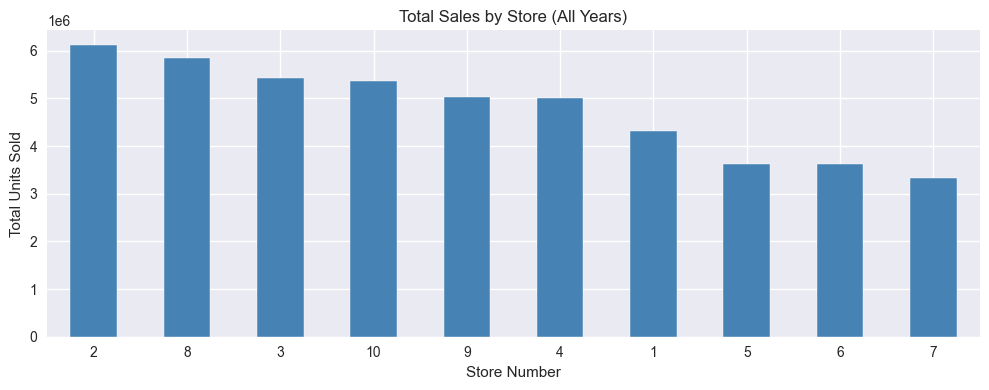

In [10]:
store_totals = df.groupby('store')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
store_totals.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Sales by Store (All Years)')
plt.xlabel('Store Number')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/sales_by_store.png', dpi=150)
plt.show()

In [11]:
# Step 06: Seasonality Decomposition

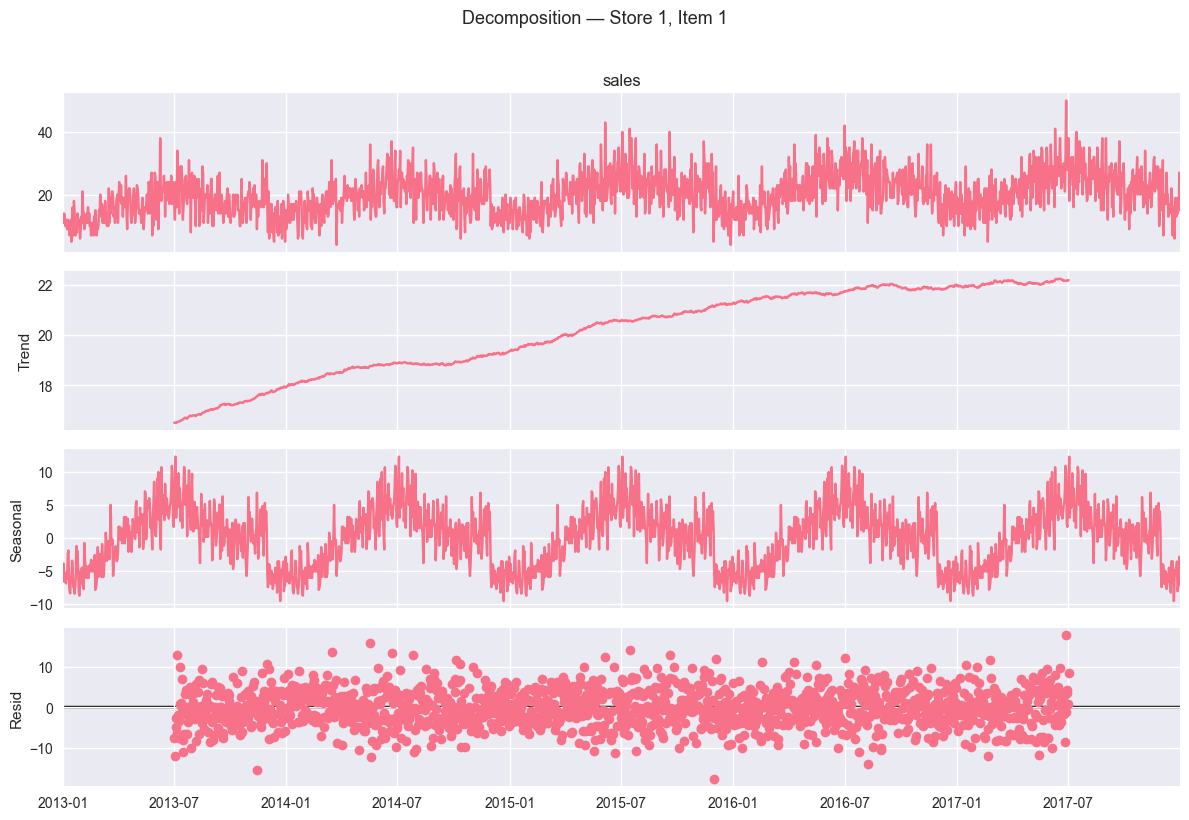

In [12]:
# Taking Store 1, Item 1 as an example
subset = df[(df['store'] == 1) & (df['item'] == 1)].set_index('date')['sales']

result = seasonal_decompose(subset, model='additive', period=365)
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Decomposition — Store 1, Item 1', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../results/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Observations

1. **Upward Trend**: Total sales increase year-over-year, indicating business growth.
2. **Weekly Seasonality**: Sales are consistently higher on weekends.
3. **Annual Seasonality**: A spike occurs in the middle of every year (summer).
4. **No Missing Data**: The dataset is clean with 913,000 complete records.
5. **Store Variation**: Store 2 has highest sales; Store 7 has lowest.

These insights directly inform our modeling choices:
- Prophet's seasonality parameters will be set to yearly + weekly
- XGBoost will include day_of_week and month as features
- LSTM sequence length will be 365 days to capture annual patterns